In [1]:
import tensorflow as tf

# List all physical GPU devices
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("GPU is available!")
    for gpu in gpus:
        print(f"GPU Name: {gpu.name}, Type: {gpu.device_type}")
else:
    print("No GPU detected!")

2025-12-06 09:03:51.971518: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765011832.185585      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765011832.247276      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

GPU is available!
GPU Name: /physical_device:GPU:0, Type: GPU
GPU Name: /physical_device:GPU:1, Type: GPU


In [8]:
DATA_DIR = '/kaggle/input/cats-and-dogs-mini-dataset/'


In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import os
import random

In [6]:
DATA_DIR = '/kaggle/working/cats_and_dogs_mini_dataset/'  # dataset path
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
SEED = 42
INITIAL_EPOCHS = 6
FINETUNE_EPOCHS = 5

In [10]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.12,
    height_shift_range=0.12,
    shear_range=0.08,
    zoom_range=0.12,
    horizontal_flip=True,
    validation_split=VALIDATION_SPLIT
)

train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=SEED,
    shuffle=False
)

print("Class indices:", train_generator.class_indices)


Found 800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Class indices: {'cats_set': 0, 'dogs_set': 1}


In [11]:
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # Freeze base layers

I0000 00:00:1765012333.999911      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765012334.000527      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
# Add classifier head
# ---------------------------
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [14]:
# Compile model
# ---------------------------
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [15]:
# Callbacks
# ---------------------------
callbacks = [
    ModelCheckpoint('/kaggle/working/vgg19_cats_dogs_best.h5', monitor='val_accuracy', save_best_only=True),
    EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
]


In [16]:
# Train classifier head
# ---------------------------
steps_per_epoch = max(1, train_generator.samples // BATCH_SIZE)
validation_steps = max(1, val_generator.samples // BATCH_SIZE)

history_head = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=INITIAL_EPOCHS,
    validation_data=val_generator,
    validation_steps=validation_steps,
    callbacks=callbacks
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/6


I0000 00:00:1765012469.598272     127 service.cc:148] XLA service 0x7de1e0005490 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765012469.599459     127 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1765012469.599481     127 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1765012470.151029     127 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/25 ━━━━━━━━━━━━━━━━━━━━ 5:34 14s/step - accuracy: 0.4688 - loss: 0.9135

I0000 00:00:1765012481.499456     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.5792 - loss: 0.7705

25/25 ━━━━━━━━━━━━━━━━━━━━ 30s 649ms/step - accuracy: 0.5812 - loss: 0.7673 - val_accuracy: 0.5365 - val_loss: 0.7379
Epoch 2/6
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.6726 - loss: 0.5879

25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 497ms/step - accuracy: 0.6735 - loss: 0.5864 - val_accuracy: 0.7292 - val_loss: 0.4935
Epoch 3/6
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.8335 - loss: 0.4533

25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 510ms/step - accuracy: 0.8327 - loss: 0.4530 - val_accuracy: 0.8177 - val_loss: 0.3983
Epoch 4/6
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step - accuracy: 0.8306 - loss: 0.3822

25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 482ms/step - accuracy: 0.8306 - loss: 0.3821 - val_accuracy: 0.8333 - val_loss: 0.3735
Epoch 5/6
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 500ms/step - accuracy: 0.8272 - loss: 0.3909 - val_accuracy: 0.8281 - val_loss: 0.3995
Epoch 6/6
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 486ms/step - accuracy: 0.8926 - loss: 0.2933 - val_accuracy: 0.8073 - val_loss: 0.3811


In [17]:
# Fine-tune last layers of VGG19
# ---------------------------
for layer in base_model.layers[-4:]:  # unfreeze last 4 layers
    layer.trainable = True

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

history_finetune = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=FINETUNE_EPOCHS,
    validation_data=val_generator,
    validation_steps=validation_steps,
    callbacks=callbacks
)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.8567 - loss: 0.3534

25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 560ms/step - accuracy: 0.8561 - loss: 0.3536 - val_accuracy: 0.8490 - val_loss: 0.3370
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 498ms/step - accuracy: 0.8908 - loss: 0.2511 - val_accuracy: 0.8073 - val_loss: 0.3624
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.8853 - loss: 0.2613

25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 514ms/step - accuracy: 0.8857 - loss: 0.2604 - val_accuracy: 0.8750 - val_loss: 0.3050
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 478ms/step - accuracy: 0.9006 - loss: 0.2597 - val_accuracy: 0.8698 - val_loss: 0.3041
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 489ms/step - accuracy: 0.8920 - loss: 0.2188 - val_accuracy: 0.8594 - val_loss: 0.2952


In [18]:
model.save('/kaggle/working/vgg19_cats_dogs_final.keras')

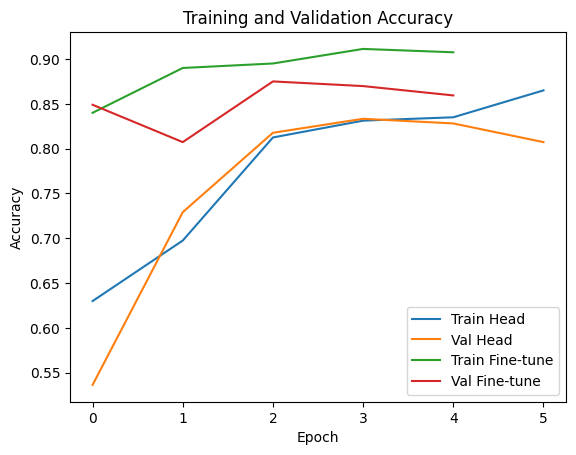

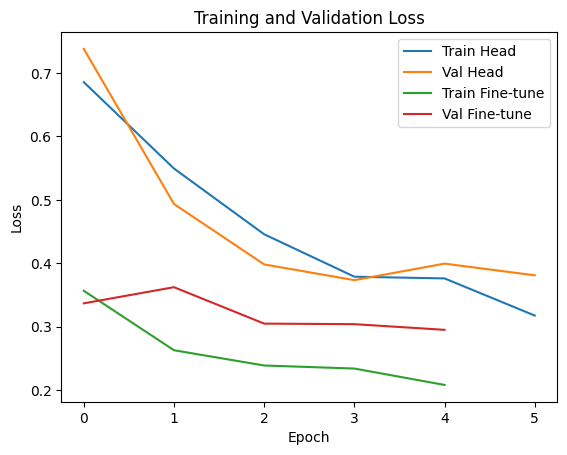

In [19]:
# Plot training history
# ---------------------------
plt.plot(history_head.history['accuracy'], label='Train Head')
plt.plot(history_head.history['val_accuracy'], label='Val Head')
plt.plot(history_finetune.history['accuracy'], label='Train Fine-tune')
plt.plot(history_finetune.history['val_accuracy'], label='Val Fine-tune')
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history_head.history['loss'], label='Train Head')
plt.plot(history_head.history['val_loss'], label='Val Head')
plt.plot(history_finetune.history['loss'], label='Train Fine-tune')
plt.plot(history_finetune.history['val_loss'], label='Val Fine-tune')
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [20]:
# Evaluate model on validation set
# ---------------------------
from sklearn.metrics import classification_report, confusion_matrix

val_generator.reset()
y_pred = model.predict(val_generator, steps=validation_steps, verbose=1)
y_pred_classes = (y_pred > 0.5).astype(int)
y_true = val_generator.classes[:len(y_pred_classes)]

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes))
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=list(val_generator.class_indices.keys())))

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 331ms/step
Confusion Matrix:
[[83 17]
 [ 8 84]]
Classification Report:
              precision    recall  f1-score   support

    cats_set       0.91      0.83      0.87       100
    dogs_set       0.83      0.91      0.87        92

    accuracy                           0.87       192
   macro avg       0.87      0.87      0.87       192
weighted avg       0.87      0.87      0.87       192



In [23]:
import os
import random
from tensorflow.keras.preprocessing import image
import numpy as np

# Pick 2 random images from each class
test_images = []
test_labels = []

for label, folder in enumerate(['cats_set', 'dogs_set']):
    folder_path = os.path.join(DATA_DIR, folder)
    files = os.listdir(folder_path)
    test_images.extend([os.path.join(folder_path, f) for f in random.sample(files, 2)])
    test_labels.extend([label]*2)

# Predict and display results
for img_path, true_label in zip(test_images, test_labels):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = np.expand_dims(image.img_to_array(img)/255.0, axis=0)
    pred = model.predict(img_array)
    pred_label = 1 if pred[0][0] > 0.5 else 0
    print(f"Image: {os.path.basename(img_path)}, True: {['Cat','Dog'][true_label]}, Predicted: {['Cat','Dog'][pred_label]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Image: cat.4365.jpg, True: Cat, Predicted: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Image: cat.4410.jpg, True: Cat, Predicted: Cat
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Image: dog.4419.jpg, True: Dog, Predicted: Dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Image: dog.4491.jpg, True: Dog, Predicted: Dog
